# Soil X-ray CT Segmentation — Detailed Prototype Development

> **Development reference:** This notebook documents the individual
> processing, thresholding, annotation, visualization, and saving steps used
> during development of the prototype. For routine use, see the simplified
> user-facing annotation workflow notebook.

Current prototype workflow:

1. Load a 3D TIFF stack.
2. Inspect image dimensions and intensity statistics.
3. Examine the image intensity histogram.
4. Optionally normalize the image if required.
5. Identify the middle slice.
6. Initialize soil matrix annotation using Otsu thresholding.
7. Load the image and labels into Napari for multiclass annotation.
8. Save the annotation for subsequent nnU-Net processing.

## 1. Load the 3D Soil X-ray CT Stack

The input data consist of a 3D TIFF stack representing a soil X-ray CT volume.
The image is loaded as a NumPy array and its dimensions, data type, and basic
intensity statistics are inspected before preprocessing.

In [16]:
# Find the TIFF
from pathlib import Path

from soilct_segmentation.image_io import load_tiff

input_dir = Path("soilct_segmentation") / "Input data"

tif_files = list(input_dir.glob("*.tif")) + list(input_dir.glob("*.tiff"))

if not tif_files:
    raise FileNotFoundError(
        f"No TIFF files found in {input_dir}"
    )

print(f"Found {len(tif_files)} TIFF file(s):")
for file in tif_files:
    print(f"  {file.name}")

Found 1 TIFF file(s):
  LuxArbor_R1_NS_Norm_16Slices.tif


In [17]:
# Load the TIFF
input_file = tif_files[0]
image = load_tiff(input_file)


--- Soil CT Image Information ---
File: LuxArbor_R1_NS_Norm_16Slices.tif
Shape (Z, Y, X): (16, 2385, 2311)
Number of slices: 16
Height: 2385
Width: 2311
Data type: uint8
Minimum intensity: 0
Maximum intensity: 232
Mean intensity: 112.42
Standard deviation: 63.30


## 2. Image Inspection

Before preprocessing and annotation, the CT volume is visually inspected using
a representative middle slice and its intensity distribution.

The middle slice provides a representative cross-section of the 3D soil volume,
while the histogram is used to examine the distribution of voxel intensities.
Zero-valued background voxels outside the soil volume are excluded from the
histogram so that they do not dominate the intensity distribution.

Number of slices: 16
Middle slice index: 7


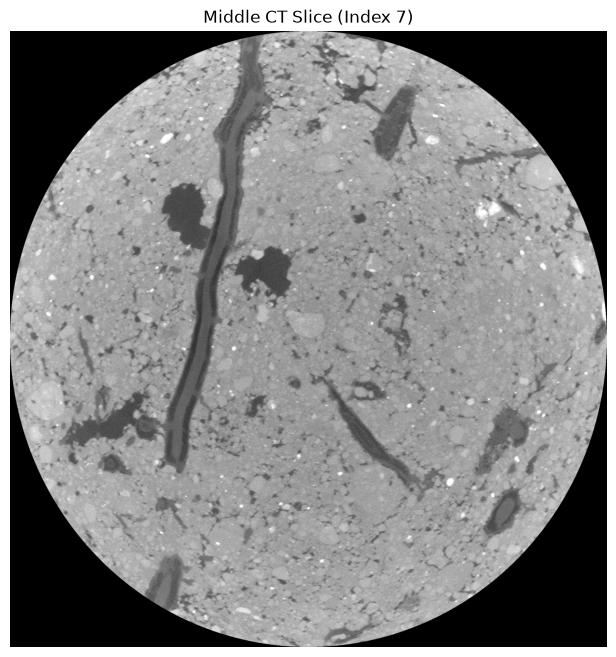

In [18]:
# Middle slice
import matplotlib.pyplot as plt

middle_slice = image.shape[0] // 2 - 1

print(f"Number of slices: {image.shape[0]}")
print(f"Middle slice index: {middle_slice}")

plt.figure(figsize=(8, 8))
plt.imshow(image[middle_slice], cmap="gray")
plt.title(f"Middle CT Slice (Index {middle_slice})")
plt.axis("off")
plt.show()

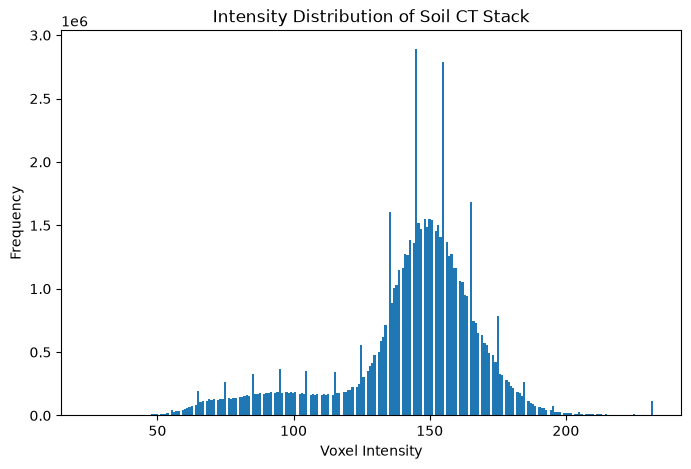

In [19]:
# Histogram
nonzero = image[image > 0]

plt.figure(figsize=(8, 5))
plt.hist(nonzero.ravel(), bins=256)
plt.xlabel("Voxel Intensity")
plt.ylabel("Frequency")
plt.title("Intensity Distribution of Soil CT Stack")
plt.show()

## 3. Optional Image Normalization

The intensity distribution is inspected before annotation to determine whether
additional normalization is required.

The preprocessing workflow provides two options:

1. **Bypass normalization** when the input image has already been normalized.
2. **Apply normalization** when additional preprocessing is required.

Background voxels with an intensity of zero are preserved as background during
normalization.

For the current prototype, the input CT stack was already normalized.
Therefore, normalization is bypassed. The normalization option is retained so
that the same workflow can later be applied to CT stacks requiring additional
intensity preprocessing.

In [20]:
# Normalization choice
from soilct_segmentation.preprocessing import normalization_decision

prepared_image = normalization_decision(image)


--- Normalization ---
1. Use image as-is
2. Normalize image to 0-255


Select option [1/2]:  1


Normalization bypassed.


In [21]:
# Verify the prepared image
print("\nPrepared Image Information")
print("--------------------------")
print(f"Shape: {prepared_image.shape}")
print(f"Data type: {prepared_image.dtype}")
print(f"Intensity range: {prepared_image.min()} - {prepared_image.max()}")


Prepared Image Information
--------------------------
Shape: (16, 2385, 2311)
Data type: uint8
Intensity range: 0 - 232


## 4. Initialization of Semi-Automatic Annotation

The annotation strategy used in this project is adapted from the
[nnUNet4SoilXrayCT](https://github.com/MaxPhal/nnUNet4SoilXrayCT)
workflow developed by Phalempin and collaborators.

In the original workflow, threshold-based initialization is used to facilitate
manual annotation of a representative slice in Napari.

In this project, Otsu thresholding is applied to the non-background voxels of
the selected middle slice. The resulting matrix mask is visually inspected
before annotation continues. If the automatically determined threshold does
not provide an appropriate initialization, the user can manually adjust the
threshold and reevaluate the result.

The final thresholded mask is used only as an initial soil matrix annotation.
It can subsequently be corrected and supplemented with additional soil classes
during manual annotation in Napari.

In [22]:
from skimage.filters import threshold_otsu

middle_image = prepared_image[middle_slice]

# Calculate Otsu threshold using only non-background voxels
# from the slice being annotated
soil_pixels = middle_image[middle_image > 0]

if soil_pixels.size == 0:
    raise ValueError("The selected slice contains no nonzero voxels.")

otsu_threshold = threshold_otsu(soil_pixels)

print(f"Middle slice index: {middle_slice}")
print(f"Otsu threshold: {otsu_threshold}")

Middle slice index: 7
Otsu threshold: 123


### Visual Inspection of the Otsu Initialization

The automatically calculated Otsu threshold is applied to the selected middle
slice to obtain an initial estimate of the soil matrix.

The proposed mask is displayed beside the original CT slice so that its
quality can be evaluated before it is used for annotation.

Because different soil constituents can have overlapping X-ray attenuation
values, the Otsu result is treated only as an initialization rather than a
final segmentation.

In [23]:
otsu_mask = middle_image > otsu_threshold

In [24]:
soil_area = middle_image > 0

print(f"Otsu threshold: {otsu_threshold}")
print(f"Matrix-mask voxels: {otsu_mask.sum():,}")
print(f"Soil-region voxels: {soil_area.sum():,}")
print(
    f"Matrix coverage within soil region: "
    f"{100 * otsu_mask.sum() / soil_area.sum():.2f}%"
)

Otsu threshold: 123
Matrix-mask voxels: 3,626,933
Soil-region voxels: 4,328,959
Matrix coverage within soil region: 83.78%


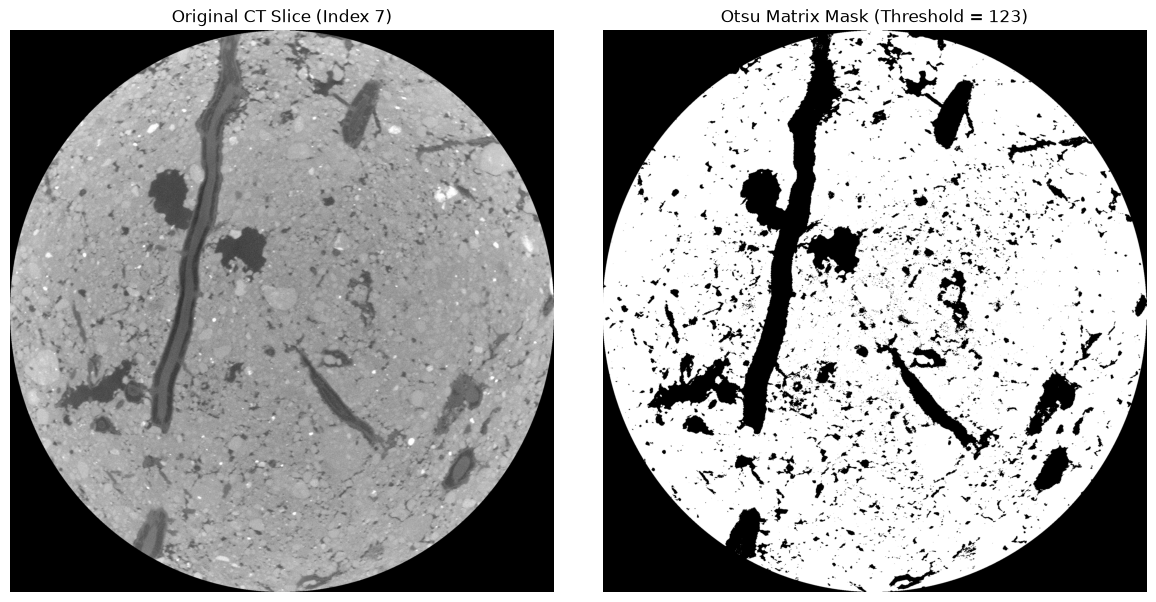

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original CT slice
axes[0].imshow(middle_image, cmap="gray")
axes[0].set_title(f"Original CT Slice (Index {middle_slice})")
axes[0].axis("off")

# Otsu mask
axes[1].imshow(otsu_mask, cmap="gray")
axes[1].set_title(f"Otsu Matrix Mask (Threshold = {otsu_threshold})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Threshold Selection

The Otsu threshold provides an automatic lower intensity threshold for the
initial soil matrix annotation. However, high-intensity materials such as
stones or mineral grains may also exceed this threshold and be incorrectly
included as matrix.

The matrix initialization is therefore defined using both a lower and an upper
intensity threshold. The lower threshold separates darker features from the
matrix, while the upper threshold excludes very bright materials.

Both thresholds are visually evaluated and can be adjusted before continuing
to multiclass annotation in Napari.

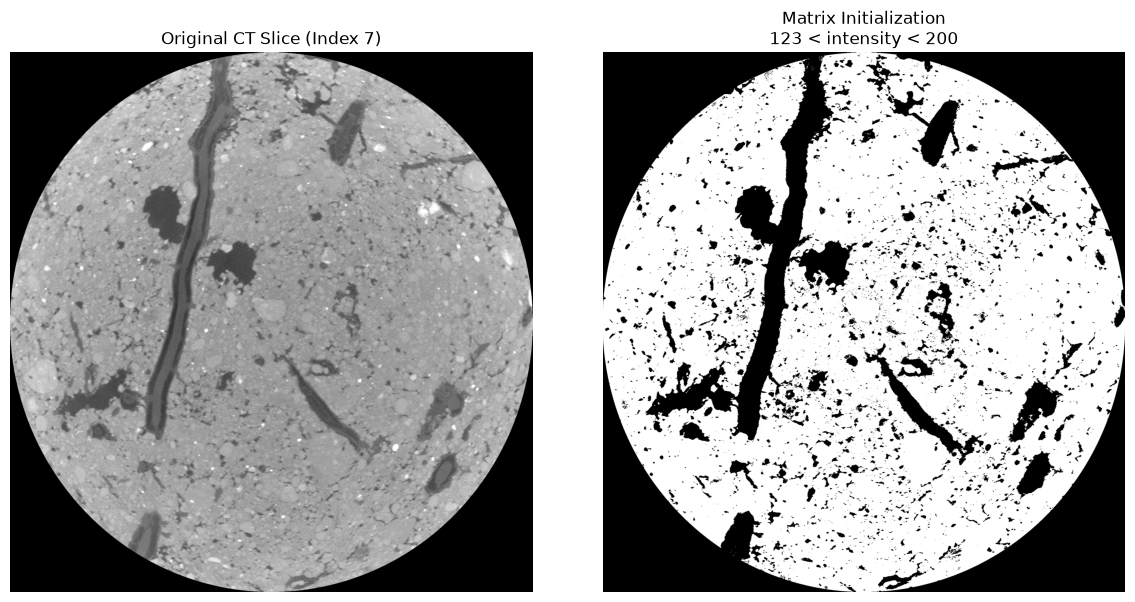

Accept these thresholds? [Y = accept / N = adjust]:  Y


Final lower threshold: 123
Final upper threshold: 200


In [26]:
lower_threshold = float(otsu_threshold)
upper_threshold = 200.0  # change if the upper threshold is excluding some matrix

while True:
    initial_matrix_mask = (
        (middle_image > lower_threshold) &
        (middle_image < upper_threshold)
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(middle_image, cmap="gray")
    axes[0].set_title(f"Original CT Slice (Index {middle_slice})")
    axes[0].axis("off")

    axes[1].imshow(initial_matrix_mask, cmap="gray")
    axes[1].set_title(
        f"Matrix Initialization\n"
        f"{lower_threshold:g} < intensity < {upper_threshold:g}"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    choice = input(
        "Accept these thresholds? [Y = accept / N = adjust]: "
    ).strip().lower()

    if choice == "y":
        print(f"Final lower threshold: {lower_threshold:g}")
        print(f"Final upper threshold: {upper_threshold:g}")
        break

    elif choice == "n":
        try:
            new_lower = float(
                input(f"Enter lower threshold [{lower_threshold:g}]: ")
            )
            new_upper = float(
                input(f"Enter upper threshold [{upper_threshold:g}]: ")
            )

            if new_lower >= new_upper:
                print("Lower threshold must be less than upper threshold.")
                continue

            if not (
                middle_image.min() <= new_lower <= middle_image.max()
                and middle_image.min() <= new_upper <= middle_image.max()
            ):
                print(
                    f"Thresholds must be between "
                    f"{middle_image.min()} and {middle_image.max()}."
                )
                continue

            lower_threshold = new_lower
            upper_threshold = new_upper

        except ValueError:
            print("Please enter numeric threshold values.")

    else:
        print("Please enter Y or N.")

In [27]:
#Summary
soil_area = middle_image > 0

print(f"Final lower threshold: {lower_threshold:g}")
print(f"Final upper threshold: {upper_threshold:g}")
print(f"Matrix voxels: {initial_matrix_mask.sum():,}")
print(
    f"Matrix coverage within soil region: "
    f"{100 * initial_matrix_mask.sum() / soil_area.sum():.2f}%"
)

Final lower threshold: 123
Final upper threshold: 200
Matrix voxels: 3,601,027
Matrix coverage within soil region: 83.18%


## 5. Prepare the 3D Annotation Volume

Class definitions and display colors are loaded from `dataset_info.json` so that
the annotation labels remain consistent throughout the workflow.

If a previously saved annotation file is available, it is loaded so that
annotation can continue from the previous session. Otherwise, a new 3D label
volume is initialized using the accepted matrix mask on the selected middle
slice.

In [37]:
import json
from pathlib import Path
import numpy as np
import tifffile

dataset_info_path = Path("dataset_info.json")

with open(dataset_info_path, "r") as file:
    dataset_info = json.load(file)

labels_by_id = dataset_info["labels"]
colors_by_id = dataset_info["colors"]

labels_by_name = {
    name: int(label_id)
    for label_id, name in labels_by_id.items()
}

print("Annotation classes:")
for label_id, class_name in labels_by_id.items():
    print(f"  {label_id}: {class_name}")

Annotation classes:
  0: ToPredict
  1: Matrix
  2: Stones
  3: OrganicMatter
  4: Roots
  5: Biopores
  6: OtherPores


In [38]:
import tifffile

TO_PREDICT = labels_by_name["ToPredict"]
MATRIX = labels_by_name["Matrix"]

annotation_dir = Path("soilct_segmentation") / "Annotations"
annotation_dir.mkdir(parents=True, exist_ok=True)

annotation_file = annotation_dir / f"{input_file.stem}_labels.tif"

if annotation_file.exists():
    labels_3d = tifffile.imread(annotation_file)

    if labels_3d.shape != prepared_image.shape:
        raise ValueError(
            f"Saved annotation shape {labels_3d.shape} does not match "
            f"image shape {prepared_image.shape}."
        )

    print("Loaded existing annotation:")
    print(f"  {annotation_file}")

else:
    labels_3d = np.full(
        prepared_image.shape,
        TO_PREDICT,
        dtype=np.uint8
    )

    labels_3d[middle_slice][initial_matrix_mask] = MATRIX

    print("No saved annotation found.")
    print("Created a new annotation volume.")
    print("Annotation will be saved to:")
    print(f"  {annotation_file}")

print("\nAnnotation volume information")
print("-----------------------------")
print(f"Image shape: {prepared_image.shape}")
print(f"Label shape: {labels_3d.shape}")
print(f"Label dtype: {labels_3d.dtype}")

Loaded existing annotation:
  soilct_segmentation\Annotations\LuxArbor_R1_NS_Norm_16Slices_labels.tif

Annotation volume information
-----------------------------
Image shape: (16, 2385, 2311)
Label shape: (16, 2385, 2311)
Label dtype: uint8


In [39]:
unique_labels, counts = np.unique(labels_3d, return_counts=True)

print("\nLabels currently present:")

for label_id, count in zip(unique_labels, counts):
    class_name = labels_by_id[str(label_id)]
    print(f"  {label_id}: {class_name} -> {count:,} voxels")


Labels currently present:
  0: ToPredict -> 84,511,913 voxels
  1: Matrix -> 3,600,255 voxels
  2: Stones -> 9,914 voxels
  4: Roots -> 3,806 voxels
  5: Biopores -> 61,872 voxels


## 6. Open the CT Volume and Labels in Napari

The prepared CT volume and the initialized 3D annotation array are loaded into
Napari for interactive multiclass annotation.

The grayscale CT image is displayed as the base image layer, while the label
volume is displayed as an editable labels layer.

In [40]:
%gui qt

import napari

viewer = napari.Viewer()

In [41]:
napari_colors = {
    int(label_id): [
        rgb[0] / 255,
        rgb[1] / 255,
        rgb[2] / 255,
        1.0
    ]
    for label_id, rgb in colors_by_id.items()
}
viewer.add_image(
    prepared_image,
    name="Soil CT",
    colormap="gray"
)

label_layer = viewer.add_labels(
    labels_3d,
    name="Annotations",
    colormap=napari_colors,
    opacity=0.7,
    blending="additive"
)

C:\Users\thotaku4\conda-envs\soilct\Lib\site-packages\napari\utils\colormaps\colormap.py:477: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


In [42]:
# 1. Define a function that saves the current Napari annotation layer

def save_annotations():
    """Save the current Napari annotation layer as a 3D TIFF stack."""

    # Read the current edited labels directly from the Napari layer
    annotation_data = np.asarray(
        label_layer.data,
        dtype=np.uint8
    )

    # Make sure the annotation output folder exists
    annotation_dir.mkdir(parents=True, exist_ok=True)

    # Save the complete 3D label volume
    tifffile.imwrite(
        annotation_file,
        annotation_data
    )

    # Report where the file was saved
    print("Annotations saved successfully:")
    print(f"  {annotation_file}")

In [35]:
# 2. Save the annotations currently open in Napari
save_annotations()

Annotations saved to:
  soilct_segmentation\Annotations\LuxArbor_R1_NS_Norm_16Slices_labels.tif


In [ ]:
# 3. Allow Ctrl+S in Napari to manually save the current annotations

@viewer.bind_key("Control-S", overwrite=True)
def manual_save(viewer):
    save_annotations()

In [36]:
# 4. Automatically save annotations when the Napari window is closed

qt_window = viewer.window._qt_window

# Install the auto-save hook only once for this Napari window
if not hasattr(qt_window, "_annotation_autosave_installed"):

    # Keep Napari's original close behavior
    original_close_event = qt_window.closeEvent

    def close_event_with_save(event):
        # Save the current annotation layer before closing
        save_annotations()

        # Continue with Napari's normal window-closing behavior
        original_close_event(event)

    # Replace the close event with the save-then-close behavior
    qt_window.closeEvent = close_event_with_save

    # Mark this window so the hook is not installed twice
    qt_window._annotation_autosave_installed = True

    print("Automatic save on Napari close is enabled.")

else:
    print("Automatic save on Napari close is already enabled.")

Automatic save on Napari close is enabled.
Annotations saved to:
  soilct_segmentation\Annotations\LuxArbor_R1_NS_Norm_16Slices_labels.tif
